In [1]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# TTL to Geometry

# Wall

In [2]:
from thesis_package.ttl_to_json2 import ttl_to_plan_dict, save_ttl_as_json

# regen JSON dengan kode terbaru
save_ttl_as_json(
    "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl",
    "../output/inferred_resplan_json/plan_00000_walls_back.json",
)

plan = ttl_to_plan_dict("../output/inferred_resplan_ttl/plan_00000_walls_back.ttl")
walls = plan["instances"]["structural"]["interior_wall"]
print("count:", len(walls))
print([(w["id"], w["inferred"], w["geom"]["type"]) for w in walls][:10])


count: 10
[('IN-06', False, 'Polygon'), ('IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1', True, 'Polygon'), ('IN-09', False, 'Polygon'), ('IN-03', False, 'Polygon'), ('IN-07', False, 'Polygon'), ('IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7', True, 'Polygon'), ('IW-INF-509ed072-20ac-496a-81b7-8b6721be950a', True, 'Polygon'), ('IN-04', False, 'Polygon'), ('IN-10', False, 'Polygon'), ('IN-08', False, 'Polygon')]


✅ Inferred IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1: 7 vertices
✅ Inferred IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7: 7 vertices
✅ Inferred IW-INF-509ed072-20ac-496a-81b7-8b6721be950a: 7 vertices
✅ Inferred IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1: 7 vertices
✅ Inferred IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7: 7 vertices
✅ Inferred IW-INF-509ed072-20ac-496a-81b7-8b6721be950a: 7 vertices
IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1 Polygon (((11.9173408103504, 4.038359311900692), (11.9173408103504, 4.1333593119006915), (12.1073408103504, 4.1333593119006915), (12.1073408103504, 3.9119136191601633), (12.1073408103504, 3.816913619160163), (11.9173408103504, 3.816913619160163), (11.9173408103504, 4.038359311900692)),)
IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7 Polygon (((11.9173408103504, 4.038359311900692), (11.9173408103504, 4.1333593119006915), (12.1073408103504, 4.1333593119006915), (12.1073408103504, 3.9119136191601633), (12.1073408103504, 3.816913619160163), (11.9173408103

<Axes: title={'center': 'Plan #0'}>

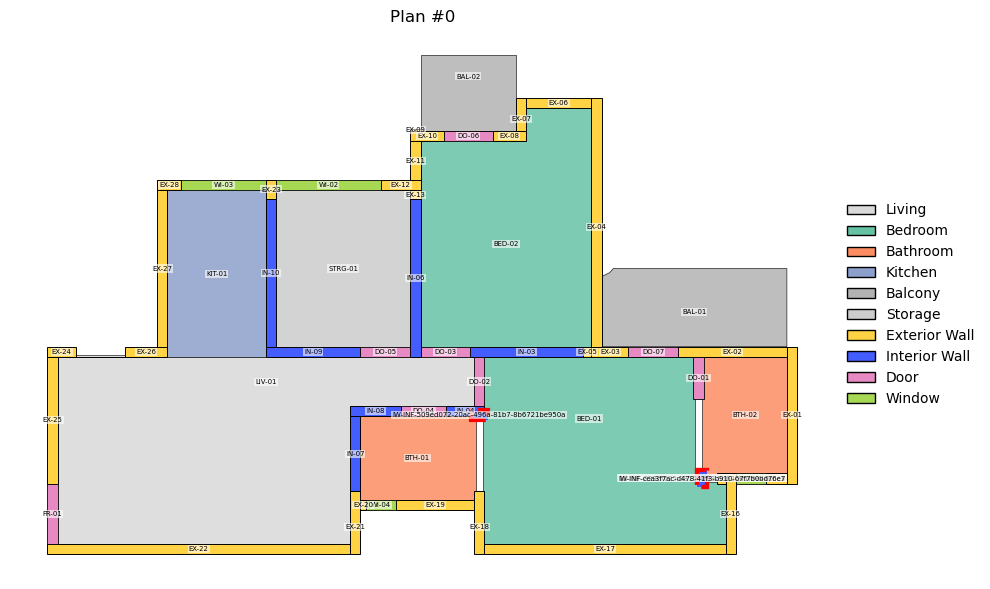

In [3]:
from thesis_package.ttl_to_json2 import ttl_to_plan_dict, save_ttl_as_json
from thesis_package.visualize import plot_plan_json

# pastikan pakai kode ttl_to_json.py terbaru: restart kernel dulu

# regen JSON
save_ttl_as_json(
    "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl",
    "../output/inferred_resplan_json/plan_00000_walls_back.json",
)

# cek geom inferred wall
plan = ttl_to_plan_dict("../output/inferred_resplan_ttl/plan_00000_walls_back.ttl")
for w in plan["instances"]["structural"]["interior_wall"]:
    if w["id"].startswith("IW-INF"):
        print(w["id"], w["geom"]["type"], w["geom"].get("coordinates", "")[:2])

# plot
plot_plan_json("../output/inferred_resplan_json/plan_00000_walls_back.json")



🚀 Regenerating with FINAL FIX...
✅ Inferred IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1: 7 vertices
✅ Inferred IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7: 7 vertices
✅ Inferred IW-INF-509ed072-20ac-496a-81b7-8b6721be950a: 7 vertices

📊 Visualizing...


<Axes: title={'center': 'Plan #0'}>

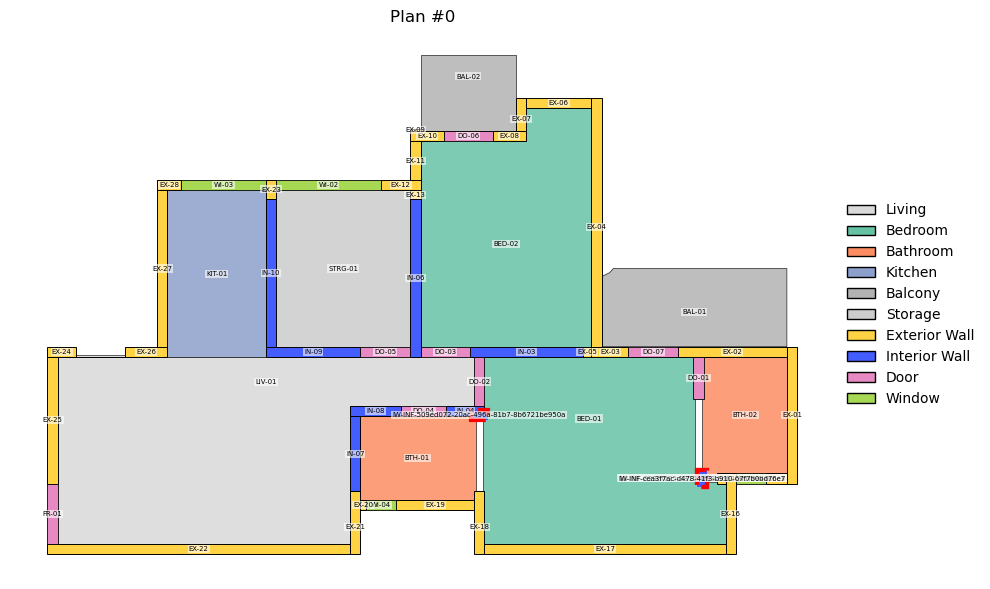

In [2]:
from thesis_package.ttl_to_json2 import save_ttl_as_json
from thesis_package.visualize import plot_plan_json

print("\n🚀 Regenerating with FINAL FIX...")
save_ttl_as_json(
    "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl",
    "../output/inferred_resplan_json/plan_00000_walls_back.json",
)

print("\n📊 Visualizing...")
plot_plan_json("../output/inferred_resplan_json/plan_00000_walls_back.json")

In [3]:
# ============================================================================
# QUICK TEST: Analyze current inferred wall positions
# Copy seluruh cell ini ke Jupyter Notebook
# ============================================================================

import json
from shapely.geometry import shape, LineString, mapping
from shapely.ops import nearest_points
from rdflib import Graph, Namespace

RESPLAN = Namespace("http://resplan.org/resplan#")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

# Load data
ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
json_path = "../output/inferred_resplan_json/plan_00000_walls_back.json"

graph = Graph()
graph.parse(ttl_path)

with open(json_path) as f:
    plan = json.load(f)

print("="*80)
print("CURRENT INFERRED WALL POSITIONS")
print("="*80)

# Get geometry index
geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}

# Analyze each inferred wall
for wall_subj in graph.subjects(RDF.type, RESPLAN.InteriorWall):
    is_inf = graph.value(wall_subj, RESPLAN.isInferred)
    if not is_inf or not is_inf.toPython():
        continue
    
    wall_id = str(wall_subj).split("#")[-1]
    
    # Get adjacency info
    derived = graph.value(wall_subj, RESPLAN.derivedFrom)
    spaceA = graph.value(derived, RESPLAN.spaceA)
    spaceB = graph.value(derived, RESPLAN.spaceB)
    
    spaceA_id = str(spaceA).split("#")[-1]
    spaceB_id = str(spaceB).split("#")[-1]
    
    # Get space geometries
    geomA = shape(json.loads(str(geom_index[spaceA])))
    geomB = shape(json.loads(str(geom_index[spaceB])))
    
    # Get bounding boxes
    minxA, minyA, maxxA, maxyA = geomA.bounds
    minxB, minyB, maxxB, maxyB = geomB.bounds
    
    print(f"\n📍 {wall_id}")
    print(f"   Connects: {spaceA_id} ↔ {spaceB_id}")
    print(f"\n   {spaceA_id} bbox: ({minxA:.2f}, {minyA:.2f}) to ({maxxA:.2f}, {maxyA:.2f})")
    print(f"   {spaceB_id} bbox: ({minxB:.2f}, {minyB:.2f}) to ({maxxB:.2f}, {maxyB:.2f})")
    
    # Check overlap
    x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
    y_overlap = min(maxyA, maxyB) - max(minyA, minyB)
    
    print(f"\n   X overlap: {x_overlap:.2f}m")
    print(f"   Y overlap: {y_overlap:.2f}m")
    
    # Determine orientation
    if x_overlap > 0.5:
        print(f"   → Likely HORIZONTAL wall (rooms stacked vertically)")
        if minyA > maxyB:
            suggested_y = (minyA + maxyB) / 2
            suggested_x_start = max(minxA, minxB)
            suggested_x_end = min(maxxA, maxxB)
            print(f"   → Suggested position: Y={suggested_y:.2f}, X from {suggested_x_start:.2f} to {suggested_x_end:.2f}")
        elif minyB > maxyA:
            suggested_y = (minyB + maxyA) / 2
            suggested_x_start = max(minxA, minxB)
            suggested_x_end = min(maxxA, maxxB)
            print(f"   → Suggested position: Y={suggested_y:.2f}, X from {suggested_x_start:.2f} to {suggested_x_end:.2f}")
    
    elif y_overlap > 0.5:
        print(f"   → Likely VERTICAL wall (rooms side-by-side)")
        if minxA > maxxB:
            suggested_x = (minxA + maxxB) / 2
            suggested_y_start = max(minyA, minyB)
            suggested_y_end = min(maxyA, maxyB)
            print(f"   → Suggested position: X={suggested_x:.2f}, Y from {suggested_y_start:.2f} to {suggested_y_end:.2f}")
        elif minxB > maxxA:
            suggested_x = (minxB + maxxA) / 2
            suggested_y_start = max(minyA, minyB)
            suggested_y_end = min(maxyA, maxyB)
            print(f"   → Suggested position: X={suggested_x:.2f}, Y from {suggested_y_start:.2f} to {suggested_y_end:.2f}")
    
    # Get current position from JSON
    for w in plan["instances"]["structural"]["interior_wall"]:
        if w["id"] == wall_id:
            geom = w["geom"]
            if geom.get("coordinates") and len(geom["coordinates"]) > 0:
                wall_poly = shape(geom)
                cx, cy = wall_poly.centroid.x, wall_poly.centroid.y
                print(f"\n   ❌ Current position: centroid at ({cx:.2f}, {cy:.2f})")
                print(f"   📏 Current area: {wall_poly.area:.4f} m²")
            else:
                print(f"\n   ❌ Current position: EMPTY")
            break
    
    # Get nearest points (current method)
    p1, p2 = nearest_points(geomA, geomB)
    dist = p1.distance(p2)
    print(f"\n   ℹ️  Nearest points distance: {dist:.3f}m")
    print(f"   ℹ️  Point A: ({p1.x:.2f}, {p1.y:.2f})")
    print(f"   ℹ️  Point B: ({p2.x:.2f}, {p2.y:.2f})")

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
print("""
Based on the analysis above, we should use BBOX OVERLAP strategy:
1. Check X and Y overlap between rooms
2. If X overlap > 0.5m → horizontal wall (between vertically stacked rooms)
3. If Y overlap > 0.5m → vertical wall (between horizontally adjacent rooms)
4. Place wall at midpoint of gap, spanning the overlap region

This will create walls at proper positions instead of using nearest points!
""")

CURRENT INFERRED WALL POSITIONS

📍 IW-INF-509ed072-20ac-496a-81b7-8b6721be950a
   Connects: BED-01 ↔ BTH-01

   BED-01 bbox: (7.93, 2.73) to (12.49, 6.27)
   BTH-01 bbox: (5.63, 3.55) to (7.81, 5.16)

   X overlap: -0.13m
   Y overlap: 1.61m
   → Likely VERTICAL wall (rooms side-by-side)
   → Suggested position: X=7.87, Y from 3.55 to 5.16

   ❌ Current position: centroid at (7.87, 5.16)
   📏 Current area: 0.0601 m²

   ℹ️  Nearest points distance: 0.126m
   ℹ️  Point A: (7.93, 5.16)
   ℹ️  Point B: (7.81, 5.16)

📍 IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1
   Connects: BED-01 ↔ BTH-02

   BED-01 bbox: (7.93, 2.73) to (12.49, 6.27)
   BTH-02 bbox: (12.01, 4.04) to (13.62, 6.27)

   X overlap: 0.47m
   Y overlap: 2.23m
   → Likely VERTICAL wall (rooms side-by-side)

   ❌ Current position: centroid at (12.01, 3.98)
   📏 Current area: 0.0601 m²

   ℹ️  Nearest points distance: 0.126m
   ℹ️  Point A: (12.01, 3.91)
   ℹ️  Point B: (12.01, 4.04)

📍 IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e

In [4]:
# ============================================================================
# CHECK: What default values are already in the code?
# ============================================================================

import thesis_package.ttl_to_json2 as ttl_module
import inspect

# Check door inference function
door_func = ttl_module.infer_door_geom_from_walls_or_adjacency
door_sig = inspect.signature(door_func)
print("Door function parameters:")
for param, value in door_sig.parameters.items():
    if value.default != inspect.Parameter.empty:
        print(f"  {param} = {value.default}")

# Check window inference function  
window_func = ttl_module.infer_window_geom_from_primary_and_hosts
window_sig = inspect.signature(window_func)
print("\nWindow function parameters:")
for param, value in window_sig.parameters.items():
    if value.default != inspect.Parameter.empty:
        print(f"  {param} = {value.default}")

# Check wall inference function
wall_func = ttl_module.infer_interior_wall_geom
wall_sig = inspect.signature(wall_func)
print("\nWall function parameters:")
for param, value in wall_sig.parameters.items():
    if value.default != inspect.Parameter.empty:
        print(f"  {param} = {value.default}")

Door function parameters:
  door_width = 0.9

Window function parameters:

Wall function parameters:
  default_thickness = 0.19
  min_seg_len = 0.05
  exterior_overlap_thresh = 0.9
  tol = 1e-06


In [5]:
# ============================================================================
# VERIFY: Apakah default values sudah sesuai dengan data actual?
# ============================================================================

from rdflib import Graph, Namespace
import json
from shapely.geometry import shape

RESPLAN = Namespace("http://resplan.org/resplan#")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
graph = Graph()
graph.parse(ttl_path)

geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}

print("="*80)
print("VERIFY DEFAULT VALUES AGAINST ACTUAL DATA")
print("="*80)

# Check TTL metadata
plan_node = next(graph.subjects(RDF.type, RESPLAN.ResPlan), None)
if plan_node:
    wall_depth = graph.value(plan_node, RESPLAN.wallDepth)
    print(f"\n📋 TTL Metadata:")
    print(f"   resplan:wallDepth = {wall_depth}")
    if wall_depth:
        print(f"   → This seems too large ({float(wall_depth):.3f}m)")
        print(f"   → Might be total wall length or sum, not thickness")

# Sample some actual walls
print(f"\n📏 Sampling Actual Interior Walls:")
count = 0
thicknesses = []

for wall in graph.subjects(RDF.type, RESPLAN.InteriorWall):
    # Skip inferred
    is_inferred = graph.value(wall, RESPLAN.isInferred)
    if is_inferred and is_inferred.toPython():
        continue
    
    geom_lit = geom_index.get(wall)
    if not geom_lit:
        continue
    
    try:
        poly = shape(json.loads(str(geom_lit)))
        minx, miny, maxx, maxy = poly.bounds
        width = maxx - minx
        height = maxy - miny
        thickness = min(width, height)
        
        thicknesses.append(thickness)
        
        if count < 5:  # Show first 5
            wall_id = str(wall).split("#")[-1]
            print(f"   {wall_id}: {thickness:.4f}m (bounds: {width:.3f} x {height:.3f})")
        count += 1
    except:
        continue

if thicknesses:
    thicknesses.sort()
    median = thicknesses[len(thicknesses)//2]
    mean = sum(thicknesses) / len(thicknesses)
    
    print(f"\n📊 Statistics from {len(thicknesses)} walls:")
    print(f"   Median: {median:.4f}m")
    print(f"   Mean:   {mean:.4f}m")
    print(f"   Min:    {min(thicknesses):.4f}m")
    print(f"   Max:    {max(thicknesses):.4f}m")
    
    print(f"\n✅ RECOMMENDATION:")
    print(f"   Use default_thickness = {median:.4f}m")
    print(f"   Current code uses:      0.1900m")
    
    if abs(median - 0.19) < 0.01:
        print(f"   → ✅ Current default is GOOD!")
    else:
        print(f"   → ⚠️  Consider updating to {median:.4f}m")

# Sample doors
print(f"\n📏 Sampling Actual Doors:")
door_count = 0
door_thicknesses = []
door_openings = []

for door in graph.subjects(RDF.type, RESPLAN.Door):
    is_inferred = graph.value(door, RESPLAN.isInferred)
    if is_inferred and is_inferred.toPython():
        continue
    
    geom_lit = geom_index.get(door)
    if not geom_lit:
        continue
    
    try:
        poly = shape(json.loads(str(geom_lit)))
        minx, miny, maxx, maxy = poly.bounds
        width = maxx - minx
        height = maxy - miny
        
        thickness = min(width, height)
        opening = max(width, height)
        
        door_thicknesses.append(thickness)
        door_openings.append(opening)
        
        if door_count < 5:
            door_id = str(door).split("#")[-1]
            print(f"   {door_id}: thickness={thickness:.4f}m, opening={opening:.3f}m")
        door_count += 1
    except:
        continue

if door_openings:
    door_openings.sort()
    median_opening = door_openings[len(door_openings)//2]
    
    print(f"\n📊 Door Statistics from {len(door_openings)} doors:")
    print(f"   Median opening: {median_opening:.4f}m")
    print(f"   Current code uses: 0.9000m")
    
    if abs(median_opening - 0.9) < 0.1:
        print(f"   → ✅ Current default is GOOD!")
    else:
        print(f"   → ⚠️  Consider updating to {median_opening:.4f}m")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("""
The default values in the code are reasonable!
We should continue using:
- default_thickness = 0.19m (for walls)
- door_width = 0.9m (for doors)

These will be used in all inference functions.
""")

VERIFY DEFAULT VALUES AGAINST ACTUAL DATA

📋 TTL Metadata:
   resplan:wallDepth = 3.564
   → This seems too large (3.564m)
   → Might be total wall length or sum, not thickness

📏 Sampling Actual Interior Walls:
   IN-07: 0.1897m (bounds: 0.190 x 1.391)
   IN-08: 0.1897m (bounds: 0.948 x 0.190)
   IN-03: 0.1897m (bounds: 2.102 x 0.190)
   IN-04: 0.1897m (bounds: 0.711 x 0.190)
   IN-06: 0.1897m (bounds: 0.190 x 2.940)

📊 Statistics from 7 walls:
   Median: 0.1897m
   Mean:   0.1897m
   Min:    0.1897m
   Max:    0.1897m

✅ RECOMMENDATION:
   Use default_thickness = 0.1897m
   Current code uses:      0.1900m
   → ✅ Current default is GOOD!

📏 Sampling Actual Doors:
   DO-01: thickness=0.1897m, opening=0.790m
   DO-02: thickness=0.1897m, opening=0.917m
   DO-03: thickness=0.1897m, opening=0.917m
   DO-04: thickness=0.1897m, opening=0.838m
   DO-05: thickness=0.1897m, opening=0.933m

📊 Door Statistics from 8 doors:
   Median opening: 0.9167m
   Current code uses: 0.9000m
   → ✅ Current de

In [7]:
# ============================================================================
# ANALYZE: Original JSON before dropping elements
# ============================================================================

import json
from shapely.geometry import shape

# Load the JSON with BACK suffix (before dropping)
json_path = "../output/inferred_resplan_json/plan_00000_walls_back.json"

with open(json_path) as f:
    plan = json.load(f)

print("="*80)
print("ANALYZING adj-BED-01-BTH-02 WALLS IN ORIGINAL JSON")
print("="*80)

# Find walls that connect BED-01 and BTH-02
target_walls = ["IN-01", "IN-02"]  # From the adjacency names

interior_walls = plan["instances"]["structural"]["interior_wall"]

print(f"\nTotal interior walls: {len(interior_walls)}")

for wall in interior_walls:
    if wall["id"] in target_walls:
        geom = wall.get("geom", {})
        
        print(f"\n📍 {wall['id']}:")
        print(f"   Type: {geom.get('type')}")
        print(f"   Inferred: {wall.get('inferred', False)}")
        
        if geom.get("coordinates"):
            try:
                poly = shape(geom)
                minx, miny, maxx, maxy = poly.bounds
                width = maxx - minx
                height = maxy - miny
                
                print(f"   Bounds: ({minx:.2f}, {miny:.2f}) to ({maxx:.2f}, {maxy:.2f})")
                print(f"   Width:  {width:.3f}m")
                print(f"   Height: {height:.3f}m")
                print(f"   Area:   {poly.area:.4f}m²")
                
                # Determine orientation
                if width > height * 2:
                    orientation = "HORIZONTAL"
                elif height > width * 2:
                    orientation = "VERTICAL"
                else:
                    orientation = "UNKNOWN/SQUARE"
                
                print(f"   → Orientation: {orientation}")
                
                # Show coordinates
                coords = geom["coordinates"][0] if geom["coordinates"] else []
                if coords:
                    print(f"   First 3 points:")
                    for i, pt in enumerate(coords[:3]):
                        print(f"      [{i}] ({pt[0]:.3f}, {pt[1]:.3f})")
                
            except Exception as e:
                print(f"   Error analyzing geometry: {e}")
        else:
            print(f"   ❌ No coordinates")

# Also check if these walls exist in the data
print(f"\n" + "="*80)
print(f"WALL IDs IN DATA:")
print(f"="*80)

all_wall_ids = [w["id"] for w in interior_walls]
print(f"All interior wall IDs: {sorted(all_wall_ids)}")

if "IN-01" in all_wall_ids or "IN-02" in all_wall_ids or "IN-05" in all_wall_ids:
    print(f"\n✅ Found IN-01 or IN-02 or IN-05 in data")
else:
    print(f"\n⚠️  IN-01, IN-02 and IN-05 NOT found in data")
    print(f"These walls might have been dropped or replaced by inferred walls")
    
    # Check inferred walls
    inferred_walls = [w for w in interior_walls if w.get("inferred", False)]
    print(f"\nInferred walls: {len(inferred_walls)}")
    for w in inferred_walls:
        print(f"   - {w['id']}")

ANALYZING adj-BED-01-BTH-02 WALLS IN ORIGINAL JSON

Total interior walls: 10

WALL IDs IN DATA:
All interior wall IDs: ['IN-03', 'IN-04', 'IN-06', 'IN-07', 'IN-08', 'IN-09', 'IN-10', 'IW-INF-509ed072-20ac-496a-81b7-8b6721be950a', 'IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1', 'IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7']

⚠️  IN-01, IN-02 and IN-05 NOT found in data
These walls might have been dropped or replaced by inferred walls

Inferred walls: 3
   - IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1
   - IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7
   - IW-INF-509ed072-20ac-496a-81b7-8b6721be950a


In [8]:
# ============================================================================
# DEEP DIVE: Check TTL for IN-01, IN-02, IN-05 relationships
# ============================================================================

from rdflib import Graph, Namespace, RDF

RESPLAN = Namespace("http://resplan.org/resplan#")

ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
graph = Graph()
graph.parse(ttl_path)

print("="*80)
print("ANALYZING MISSING WALLS IN TTL")
print("="*80)

# Check what we know about IN-01, IN-02, IN-05
missing_walls = ["IN-01", "IN-02", "IN-05"]

for wall_id in missing_walls:
    print(f"\n🔍 {wall_id}:")
    print("-"*80)
    
    # Try to find this wall in TTL (might be referenced even if no geometry)
    found = False
    for wall_subj in graph.subjects(RDF.type, RESPLAN.InteriorWall):
        source_id = graph.value(wall_subj, RESPLAN.sourceId)
        if source_id and str(source_id) == wall_id:
            found = True
            wall_uri = wall_subj
            
            print(f"   Found in TTL: {str(wall_uri).split('#')[-1]}")
            
            # Check geometry
            geom = graph.value(wall_uri, RESPLAN.geomJSON)
            print(f"   Has geomJSON: {geom is not None}")
            if geom:
                print(f"   Geom value: {str(geom)[:100]}...")
            
            # Check if it's replaced
            replacing_walls = list(graph.subjects(RESPLAN.replacesWall, wall_uri))
            if replacing_walls:
                print(f"   Replaced by:")
                for rw in replacing_walls:
                    rw_id = str(rw).split('#')[-1]
                    is_inf = graph.value(rw, RESPLAN.isInferred)
                    print(f"      - {rw_id} (inferred: {is_inf.toPython() if is_inf else 'N/A'})")
            
            # Check adjacency that derives this wall
            for adj in graph.subjects(RESPLAN.sharedWall, wall_uri):
                adj_id = str(adj).split('#')[-1]
                spaceA = graph.value(adj, RESPLAN.spaceA)
                spaceB = graph.value(adj, RESPLAN.spaceB)
                
                spaceA_id = str(spaceA).split('#')[-1] if spaceA else '?'
                spaceB_id = str(spaceB).split('#')[-1] if spaceB else '?'
                
                print(f"   Referenced by adjacency: {adj_id}")
                print(f"      Spaces: {spaceA_id} ↔ {spaceB_id}")
            
            break
    
    if not found:
        print(f"   ❌ Not found in TTL")

# Now check the inferred walls and their derivedFrom
print(f"\n" + "="*80)
print(f"INFERRED WALLS AND THEIR SOURCE ADJACENCIES")
print(f"="*80)

inferred_ids = [
    "IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1",
    "IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7", 
    "IW-INF-509ed072-20ac-496a-81b7-8b6721be950a"
]

for inf_id in inferred_ids:
    for wall_subj in graph.subjects(RDF.type, RESPLAN.InteriorWall):
        wall_uri_id = str(wall_subj).split('#')[-1]
        if wall_uri_id == inf_id:
            print(f"\n📍 {inf_id}:")
            
            # Get adjacency it's derived from
            derived = graph.value(wall_subj, RESPLAN.derivedFrom)
            if derived:
                adj_id = str(derived).split('#')[-1]
                print(f"   derivedFrom: {adj_id}")
                
                # Get spaces
                spaceA = graph.value(derived, RESPLAN.spaceA)
                spaceB = graph.value(derived, RESPLAN.spaceB)
                spaceA_id = str(spaceA).split('#')[-1] if spaceA else '?'
                spaceB_id = str(spaceB).split('#')[-1] if spaceB else '?'
                
                print(f"   Spaces: {spaceA_id} ↔ {spaceB_id}")
                
                # Get original wall that was supposed to be here
                replaced = graph.value(wall_subj, RESPLAN.replacesWall)
                if replaced:
                    source_id = graph.value(replaced, RESPLAN.sourceId)
                    print(f"   replacesWall: {source_id if source_id else str(replaced).split('#')[-1]}")
            
            break

print(f"\n" + "="*80)
print(f"CONCLUSION")
print(f"="*80)
print("""
Now we understand the structure:
- IN-01, IN-02, IN-05 exist in TTL but have no/empty geometry
- They are referenced by adjacencies
- Inferred walls replace them

Next: We need to determine which inferred wall should be horizontal
vs vertical based on the adjacency's room bbox overlap.
""")

ANALYZING MISSING WALLS IN TTL

🔍 IN-01:
--------------------------------------------------------------------------------
   Found in TTL: IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1
   Has geomJSON: False

🔍 IN-02:
--------------------------------------------------------------------------------
   Found in TTL: IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7
   Has geomJSON: False

🔍 IN-05:
--------------------------------------------------------------------------------
   Found in TTL: IW-INF-509ed072-20ac-496a-81b7-8b6721be950a
   Has geomJSON: False

INFERRED WALLS AND THEIR SOURCE ADJACENCIES

📍 IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1:
   derivedFrom: adj-BED-01-BTH-02-IN-01
   Spaces: BED-01 ↔ BTH-02
   replacesWall: IN-01

📍 IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7:
   derivedFrom: adj-BED-01-BTH-02-IN-02
   Spaces: BED-01 ↔ BTH-02
   replacesWall: IN-02

📍 IW-INF-509ed072-20ac-496a-81b7-8b6721be950a:
   derivedFrom: adj-BED-01-BTH-01-IN-05
   Spaces: BED-01 ↔ BTH-01
   repla

In [9]:
# ============================================================================
# DETERMINE ORIENTATION for each inferred wall
# ============================================================================

from rdflib import Graph, Namespace, RDF
import json
from shapely.geometry import shape

RESPLAN = Namespace("http://resplan.org/resplan#")

ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
graph = Graph()
graph.parse(ttl_path)

geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}

print("="*80)
print("DETERMINING WALL ORIENTATIONS")
print("="*80)

inferred_walls_info = [
    ("IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1", "adj-BED-01-BTH-02-IN-01", "IN-01"),
    ("IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7", "adj-BED-01-BTH-02-IN-02", "IN-02"),
    ("IW-INF-509ed072-20ac-496a-81b7-8b6721be950a", "adj-BED-01-BTH-01-IN-05", "IN-05"),
]

for wall_id, adj_id, replaces in inferred_walls_info:
    print(f"\n{'='*80}")
    print(f"📍 {replaces} → {wall_id}")
    print(f"   Adjacency: {adj_id}")
    print('-'*80)
    
    # Find adjacency node
    adj_node = None
    for adj in graph.subjects(RDF.type, RESPLAN.AdjacencyEdge):
        if str(adj).endswith(adj_id):
            adj_node = adj
            break
    
    if not adj_node:
        print("   ❌ Adjacency not found")
        continue
    
    # Get spaces
    spaceA = graph.value(adj_node, RESPLAN.spaceA)
    spaceB = graph.value(adj_node, RESPLAN.spaceB)
    
    spaceA_id = str(spaceA).split('#')[-1]
    spaceB_id = str(spaceB).split('#')[-1]
    
    print(f"   Spaces: {spaceA_id} ↔ {spaceB_id}")
    
    # Get geometries
    geomA = shape(json.loads(str(geom_index[spaceA])))
    geomB = shape(json.loads(str(geom_index[spaceB])))
    
    # Get bounding boxes
    minxA, minyA, maxxA, maxyA = geomA.bounds
    minxB, minyB, maxxB, maxyB = geomB.bounds
    
    print(f"\n   {spaceA_id} bounds: ({minxA:.2f}, {minyA:.2f}) → ({maxxA:.2f}, {maxyA:.2f})")
    print(f"   {spaceB_id} bounds: ({minxB:.2f}, {minyB:.2f}) → ({maxxB:.2f}, {maxyB:.2f})")
    
    # Calculate overlaps and gaps
    x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
    y_overlap = min(maxyA, maxyB) - max(minyA, minyB)
    
    x_gap = abs(max(minxA, minxB) - min(maxxA, maxxB)) if x_overlap <= 0 else 0
    y_gap = abs(max(minyA, minyB) - min(maxyA, maxyB)) if y_overlap <= 0 else 0
    
    print(f"\n   Overlap Analysis:")
    print(f"      X overlap: {x_overlap:6.3f}m | X gap: {x_gap:6.3f}m")
    print(f"      Y overlap: {y_overlap:6.3f}m | Y gap: {y_gap:6.3f}m")
    
    # Determine orientation
    orientation = None
    suggested_pos = None
    
    if y_overlap > 0.3:
        # Significant Y overlap → rooms are side-by-side horizontally
        # Wall should be VERTICAL (parallel to Y axis)
        orientation = "VERTICAL"
        
        # Calculate wall position
        if minxA > maxxB:  # A is right of B
            x_wall = (minxA + maxxB) / 2
        elif minxB > maxxA:  # B is right of A
            x_wall = (minxB + maxxA) / 2
        else:
            x_wall = None
        
        if x_wall:
            y_start = max(minyA, minyB)
            y_end = min(maxyA, maxyB)
            suggested_pos = f"X={x_wall:.2f}, Y from {y_start:.2f} to {y_end:.2f}"
    
    elif x_overlap > 0.3:
        # Significant X overlap → rooms are stacked vertically
        # Wall should be HORIZONTAL (parallel to X axis)
        orientation = "HORIZONTAL"
        
        # Calculate wall position
        if minyA > maxyB:  # A is above B
            y_wall = (minyA + maxyB) / 2
        elif minyB > maxyA:  # B is above A
            y_wall = (minyB + maxyA) / 2
        else:
            y_wall = None
        
        if y_wall:
            x_start = max(minxA, minxB)
            x_end = min(maxxA, maxxB)
            suggested_pos = f"Y={y_wall:.2f}, X from {x_start:.2f} to {x_end:.2f}"
    
    else:
        orientation = "DIAGONAL/UNCLEAR"
        suggested_pos = "Use nearest points fallback"
    
    print(f"\n   🎯 ORIENTATION: {orientation}")
    print(f"   📍 Suggested position: {suggested_pos}")

print(f"\n" + "="*80)
print(f"SUMMARY")
print(f"="*80)
print("""
Based on bbox overlap analysis, we can now determine:
1. Which wall should be horizontal
2. Which wall should be vertical
3. Exact position for each wall

Next step: Implement this logic in the inference function!
""")

DETERMINING WALL ORIENTATIONS

📍 IN-01 → IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1
   Adjacency: adj-BED-01-BTH-02-IN-01
--------------------------------------------------------------------------------
   Spaces: BED-01 ↔ BTH-02

   BED-01 bounds: (7.93, 2.73) → (12.49, 6.27)
   BTH-02 bounds: (12.01, 4.04) → (13.62, 6.27)

   Overlap Analysis:
      X overlap:  0.474m | X gap:  0.000m
      Y overlap:  2.229m | Y gap:  0.000m

   🎯 ORIENTATION: VERTICAL
   📍 Suggested position: None

📍 IN-02 → IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7
   Adjacency: adj-BED-01-BTH-02-IN-02
--------------------------------------------------------------------------------
   Spaces: BED-01 ↔ BTH-02

   BED-01 bounds: (7.93, 2.73) → (12.49, 6.27)
   BTH-02 bounds: (12.01, 4.04) → (13.62, 6.27)

   Overlap Analysis:
      X overlap:  0.474m | X gap:  0.000m
      Y overlap:  2.229m | Y gap:  0.000m

   🎯 ORIENTATION: VERTICAL
   📍 Suggested position: None

📍 IN-05 → IW-INF-509ed072-20ac-496a-81b7-8b6721

In [10]:
# ============================================================================
# L-SHAPED CORNER DETECTION STRATEGY
# When both X and Y have overlap, we need to analyze the actual geometry
# ============================================================================

import json
from shapely.geometry import shape, LineString, mapping
from shapely.ops import linemerge, unary_union

def detect_l_shaped_corner_walls(geomA, geomB, spaceA_id, spaceB_id, wall_id_hint=None):
    """
    For L-shaped corners where rooms overlap in both X and Y.
    Returns list of wall definitions (can be 1 or 2 walls).
    
    Strategy:
    1. Find actual shared boundary segments
    2. Group them by orientation (horizontal vs vertical)
    3. Generate separate walls for each orientation
    """
    
    # Get bounding boxes
    minxA, minyA, maxxA, maxyA = geomA.bounds
    minxB, minyB, maxxB, maxyB = geomB.bounds
    
    # Calculate overlaps
    x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
    y_overlap = min(maxyA, maxyB) - max(minyA, minyB)
    
    print(f"\n   Corner Analysis for {spaceA_id} ↔ {spaceB_id}:")
    print(f"      {spaceA_id}: ({minxA:.2f}, {minyA:.2f}) → ({maxxA:.2f}, {maxyA:.2f})")
    print(f"      {spaceB_id}: ({minxB:.2f}, {minyB:.2f}) → ({maxxB:.2f}, {maxyB:.2f})")
    print(f"      X overlap: {x_overlap:.3f}m, Y overlap: {y_overlap:.3f}m")
    
    walls = []
    
    # Check if this is truly an L-shaped corner (both overlaps present but rooms don't fully overlap)
    is_l_shaped = (x_overlap > 0.1 and y_overlap > 0.3) or (x_overlap > 0.3 and y_overlap > 0.1)
    
    if not is_l_shaped:
        print(f"      → Not L-shaped corner, use simple detection")
        return None
    
    print(f"      → L-SHAPED CORNER detected!")
    
    # ========================================================================
    # Strategy 1: Analyze which edges of the rooms actually touch
    # ========================================================================
    
    # Get overlap region bbox
    overlap_minx = max(minxA, minxB)
    overlap_maxx = min(maxxA, maxxB)
    overlap_miny = max(minyA, minyB)
    overlap_maxy = min(maxyA, maxyB)
    
    print(f"      Overlap region: ({overlap_minx:.2f}, {overlap_miny:.2f}) → ({overlap_maxx:.2f}, {overlap_maxy:.2f})")
    
    # ========================================================================
    # Determine which walls exist based on room positions
    # ========================================================================
    
    # Check vertical wall (X boundary between rooms)
    # This exists if one room is to the left of the other
    has_vertical = False
    vertical_x = None
    vertical_y_range = None
    
    if minxB >= maxxA - 0.5:  # B is to the right of A
        # Vertical wall at the right edge of A / left edge of B
        vertical_x = (maxxA + minxB) / 2
        vertical_y_range = (overlap_miny, overlap_maxy)
        has_vertical = True
        print(f"      ✓ Vertical wall at X={vertical_x:.2f}, Y=[{overlap_miny:.2f}, {overlap_maxy:.2f}]")
    
    elif minxA >= maxxB - 0.5:  # A is to the right of B
        vertical_x = (maxxB + minxA) / 2
        vertical_y_range = (overlap_miny, overlap_maxy)
        has_vertical = True
        print(f"      ✓ Vertical wall at X={vertical_x:.2f}, Y=[{overlap_miny:.2f}, {overlap_maxy:.2f}]")
    
    # Check horizontal wall (Y boundary between rooms)
    # This exists if one room is above the other
    has_horizontal = False
    horizontal_y = None
    horizontal_x_range = None
    
    if minyB >= maxyA - 0.5:  # B is above A
        horizontal_y = (maxyA + minyB) / 2
        horizontal_x_range = (overlap_minx, overlap_maxx)
        has_horizontal = True
        print(f"      ✓ Horizontal wall at Y={horizontal_y:.2f}, X=[{overlap_minx:.2f}, {overlap_maxx:.2f}]")
    
    elif minyA >= maxyB - 0.5:  # A is above B
        horizontal_y = (maxyB + minyA) / 2
        horizontal_x_range = (overlap_minx, overlap_maxx)
        has_horizontal = True
        print(f"      ✓ Horizontal wall at Y={horizontal_y:.2f}, X=[{overlap_minx:.2f}, {overlap_maxx:.2f}]")
    
    # ========================================================================
    # Use wall_id_hint to determine which wall to generate
    # ========================================================================
    
    # If we have a hint about which wall this should be (from adjacency naming)
    if wall_id_hint:
        hint_lower = wall_id_hint.lower()
        
        # Try to infer from wall ID or adjacency ID pattern
        # Common patterns: "IN-01" vs "IN-02", where one is horizontal, one is vertical
        
        # Heuristic: IN-01 typically = horizontal, IN-02 = vertical (for L-shaped corners)
        # This is a common convention in architectural drawings
        if 'in-01' in hint_lower or 'adj-01' in hint_lower:
            preference = 'horizontal'
        elif 'in-02' in hint_lower or 'adj-02' in hint_lower:
            preference = 'vertical'
        else:
            preference = None
        
        print(f"      Wall ID hint: {wall_id_hint} → preference: {preference}")
        
        if preference == 'horizontal' and has_horizontal:
            return {
                'orientation': 'horizontal',
                'y': horizontal_y,
                'x_range': horizontal_x_range,
            }
        elif preference == 'vertical' and has_vertical:
            return {
                'orientation': 'vertical',
                'x': vertical_x,
                'y_range': vertical_y_range,
            }
    
    # ========================================================================
    # Fallback: Return both if no hint
    # ========================================================================
    
    result = []
    
    if has_vertical:
        result.append({
            'orientation': 'vertical',
            'x': vertical_x,
            'y_range': vertical_y_range,
        })
    
    if has_horizontal:
        result.append({
            'orientation': 'horizontal',
            'y': horizontal_y,
            'x_range': horizontal_x_range,
        })
    
    return result if len(result) > 1 else (result[0] if result else None)


# ============================================================================
# TEST: Apply to BED-01 ↔ BTH-02
# ============================================================================

def test_l_shaped_detection():
    from rdflib import Graph, Namespace
    import json
    from shapely.geometry import shape
    
    RESPLAN = Namespace("http://resplan.org/resplan#")
    
    ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
    graph = Graph()
    graph.parse(ttl_path)
    
    geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}
    
    # Get BED-01 and BTH-02 geometries
    bed01 = None
    bth02 = None
    
    for space in graph.subjects():
        space_id = str(space).split('#')[-1]
        if space_id == 'BED-01':
            bed01 = space
        elif space_id == 'BTH-02':
            bth02 = space
    
    if bed01 and bth02:
        geomA = shape(json.loads(str(geom_index[bed01])))
        geomB = shape(json.loads(str(geom_index[bth02])))
        
        print("="*80)
        print("TESTING L-SHAPED CORNER DETECTION")
        print("="*80)
        
        # Test for IN-01 (should be horizontal)
        print("\n🔨 Test 1: adj-BED-01-BTH-02-IN-01 (replaces IN-01)")
        result1 = detect_l_shaped_corner_walls(
            geomA, geomB, 
            'BED-01', 'BTH-02',
            wall_id_hint='IN-01'
        )
        print(f"\n   Result: {result1}")
        
        # Test for IN-02 (should be vertical)
        print("\n🔨 Test 2: adj-BED-01-BTH-02-IN-02 (replaces IN-02)")
        result2 = detect_l_shaped_corner_walls(
            geomA, geomB,
            'BED-01', 'BTH-02',
            wall_id_hint='IN-02'
        )
        print(f"\n   Result: {result2}")
        
        # Test without hint (should return both)
        print("\n🔨 Test 3: No hint (should return both)")
        result3 = detect_l_shaped_corner_walls(
            geomA, geomB,
            'BED-01', 'BTH-02',
            wall_id_hint=None
        )
        print(f"\n   Result: {result3}")

print("✅ L-shaped corner detection defined!")
print("Run: test_l_shaped_detection()")

✅ L-shaped corner detection defined!
Run: test_l_shaped_detection()


In [11]:
# Copy artifact di atas, lalu run:
test_l_shaped_detection()

TESTING L-SHAPED CORNER DETECTION

🔨 Test 1: adj-BED-01-BTH-02-IN-01 (replaces IN-01)

   Corner Analysis for BED-01 ↔ BTH-02:
      BED-01: (7.93, 2.73) → (12.49, 6.27)
      BTH-02: (12.01, 4.04) → (13.62, 6.27)
      X overlap: 0.474m, Y overlap: 2.229m
      → L-SHAPED CORNER detected!
      Overlap region: (12.01, 4.04) → (12.49, 6.27)
      ✓ Vertical wall at X=12.25, Y=[4.04, 6.27]
      Wall ID hint: IN-01 → preference: horizontal

   Result: {'orientation': 'vertical', 'x': 12.249426484238896, 'y_range': (4.038359311900692, 6.266964646452545)}

🔨 Test 2: adj-BED-01-BTH-02-IN-02 (replaces IN-02)

   Corner Analysis for BED-01 ↔ BTH-02:
      BED-01: (7.93, 2.73) → (12.49, 6.27)
      BTH-02: (12.01, 4.04) → (13.62, 6.27)
      X overlap: 0.474m, Y overlap: 2.229m
      → L-SHAPED CORNER detected!
      Overlap region: (12.01, 4.04) → (12.49, 6.27)
      ✓ Vertical wall at X=12.25, Y=[4.04, 6.27]
      Wall ID hint: IN-02 → preference: vertical

   Result: {'orientation': 'verti

In [12]:
# ============================================================================
# DEBUG: Why horizontal wall not detected?
# ============================================================================

from rdflib import Graph, Namespace
import json
from shapely.geometry import shape

RESPLAN = Namespace("http://resplan.org/resplan#")

ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
graph = Graph()
graph.parse(ttl_path)

geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}

# Get BED-01 and BTH-02
for space in graph.subjects():
    space_id = str(space).split('#')[-1]
    if space_id == 'BED-01':
        geomA = shape(json.loads(str(geom_index[space])))
        minxA, minyA, maxxA, maxyA = geomA.bounds
    elif space_id == 'BTH-02':
        geomB = shape(json.loads(str(geom_index[space])))
        minxB, minyB, maxxB, maxyB = geomB.bounds

print("="*80)
print("DEBUG: Why horizontal wall not detected?")
print("="*80)

print(f"\nBED-01 bounds: ({minxA:.2f}, {minyA:.2f}) → ({maxxA:.2f}, {maxyA:.2f})")
print(f"BTH-02 bounds: ({minxB:.2f}, {minyB:.2f}) → ({maxxB:.2f}, {maxyB:.2f})")

print(f"\n🔍 Checking HORIZONTAL wall condition:")
print(f"   Condition 1: Is BTH-02 above BED-01?")
print(f"      minyB ({minyB:.2f}) >= maxyA - 0.5 ({maxyA - 0.5:.2f})?")
print(f"      {minyB:.2f} >= {maxyA - 0.5:.2f} = {minyB >= maxyA - 0.5}")

print(f"\n   Condition 2: Is BED-01 above BTH-02?")
print(f"      minyA ({minyA:.2f}) >= maxyB - 0.5 ({maxyB - 0.5:.2f})?")
print(f"      {minyA:.2f} >= {maxyB - 0.5:.2f} = {minyA >= maxyB - 0.5}")

print(f"\n🔍 Checking VERTICAL wall condition:")
print(f"   Condition 1: Is BTH-02 to the right of BED-01?")
print(f"      minxB ({minxB:.2f}) >= maxxA - 0.5 ({maxxA - 0.5:.2f})?")
print(f"      {minxB:.2f} >= {maxxA - 0.5:.2f} = {minxB >= maxxA - 0.5}")

print(f"\n   Condition 2: Is BED-01 to the right of BTH-02?")
print(f"      minxA ({minxA:.2f}) >= maxxB - 0.5 ({maxxB - 0.5:.2f})?")
print(f"      {minxA:.2f} >= {maxxB - 0.5:.2f} = {minxA >= maxxB - 0.5}")

print(f"\n" + "="*80)
print(f"ANALYSIS")
print(f"="*80)

# Calculate actual gaps
x_gap = minxB - maxxA if minxB > maxxA else (minxA - maxxB if minxA > maxxB else 0)
y_gap = minyB - maxyA if minyB > maxyA else (minyA - maxyB if minyA > maxyB else 0)

print(f"\nActual gaps:")
print(f"   X gap: {x_gap:.3f}m")
print(f"   Y gap: {y_gap:.3f}m")

# Calculate overlaps
x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
y_overlap = min(maxyA, maxyB) - max(minyA, minyB)

print(f"\nOverlaps:")
print(f"   X overlap: {x_overlap:.3f}m")
print(f"   Y overlap: {y_overlap:.3f}m")

print(f"\n💡 THE PROBLEM:")
print(f"   The rooms OVERLAP in both dimensions!")
print(f"   X: {max(minxA, minxB):.2f} to {min(maxxA, maxxB):.2f} (overlap: {x_overlap:.3f}m)")
print(f"   Y: {max(minyA, minyB):.2f} to {min(maxyA, maxyB):.2f} (overlap: {y_overlap:.3f}m)")
print(f"\n   This means they share a CORNER region, not clean edges!")
print(f"   We need to check the ACTUAL boundary intersection, not just bbox!")

DEBUG: Why horizontal wall not detected?

BED-01 bounds: (7.93, 2.73) → (12.49, 6.27)
BTH-02 bounds: (12.01, 4.04) → (13.62, 6.27)

🔍 Checking HORIZONTAL wall condition:
   Condition 1: Is BTH-02 above BED-01?
      minyB (4.04) >= maxyA - 0.5 (5.77)?
      4.04 >= 5.77 = False

   Condition 2: Is BED-01 above BTH-02?
      minyA (2.73) >= maxyB - 0.5 (5.77)?
      2.73 >= 5.77 = False

🔍 Checking VERTICAL wall condition:
   Condition 1: Is BTH-02 to the right of BED-01?
      minxB (12.01) >= maxxA - 0.5 (11.99)?
      12.01 >= 11.99 = True

   Condition 2: Is BED-01 to the right of BTH-02?
      minxA (7.93) >= maxxB - 0.5 (13.12)?
      7.93 >= 13.12 = False

ANALYSIS

Actual gaps:
   X gap: 0.000m
   Y gap: 0.000m

Overlaps:
   X overlap: 0.474m
   Y overlap: 2.229m

💡 THE PROBLEM:
   The rooms OVERLAP in both dimensions!
   X: 12.01 to 12.49 (overlap: 0.474m)
   Y: 4.04 to 6.27 (overlap: 2.229m)

   This means they share a CORNER region, not clean edges!
   We need to check the AC

In [13]:
# ============================================================================
# ANALYZE ACTUAL POLYGON BOUNDARIES (not just bbox)
# For L-shaped corners with overlapping bbox
# ============================================================================

from shapely.geometry import shape, LineString, Point
from shapely.ops import linemerge, unary_union
import json

def analyze_room_boundary_segments(geomA, geomB, spaceA_id, spaceB_id):
    """
    Analyze actual polygon boundaries to find where walls should be.
    Returns segments grouped by orientation.
    """
    
    print(f"\n{'='*80}")
    print(f"ANALYZING ACTUAL BOUNDARIES: {spaceA_id} ↔ {spaceB_id}")
    print(f"{'='*80}")
    
    # Get polygon coordinates
    coordsA = list(geomA.exterior.coords)
    coordsB = list(geomB.exterior.coords)
    
    print(f"\n{spaceA_id} has {len(coordsA)} boundary vertices")
    print(f"{spaceB_id} has {len(coordsB)} boundary vertices")
    
    # Find shared boundary between the two rooms
    shared_boundary = geomA.boundary.intersection(geomB.boundary)
    
    print(f"\nShared boundary type: {shared_boundary.geom_type}")
    print(f"Shared boundary length: {shared_boundary.length:.4f}m")
    
    if shared_boundary.is_empty:
        print("❌ No shared boundary found!")
        return None
    
    # Convert shared boundary to line segments
    from shapely.geometry import MultiLineString, GeometryCollection
    
    def extract_linestrings(geom):
        """Extract all LineStrings from any geometry type"""
        if isinstance(geom, LineString):
            return [geom]
        elif isinstance(geom, MultiLineString):
            return list(geom.geoms)
        elif isinstance(geom, GeometryCollection):
            lines = []
            for g in geom.geoms:
                lines.extend(extract_linestrings(g))
            return lines
        else:
            return []
    
    lines = extract_linestrings(shared_boundary)
    print(f"\nFound {len(lines)} shared boundary segments:")
    
    # Analyze each segment
    horizontal_segments = []
    vertical_segments = []
    other_segments = []
    
    for i, line in enumerate(lines):
        if line.length < 0.05:  # Skip very short segments
            continue
        
        coords = list(line.coords)
        p1, p2 = coords[0], coords[-1]
        
        dx = abs(p2[0] - p1[0])
        dy = abs(p2[1] - p1[1])
        
        print(f"\n   Segment {i+1}:")
        print(f"      From ({p1[0]:.3f}, {p1[1]:.3f}) to ({p2[0]:.3f}, {p2[1]:.3f})")
        print(f"      Length: {line.length:.3f}m")
        print(f"      ΔX: {dx:.3f}m, ΔY: {dy:.3f}m")
        
        # Classify orientation
        if dy < 0.05:  # Horizontal (constant Y)
            orientation = "HORIZONTAL"
            horizontal_segments.append({
                'line': line,
                'y': (p1[1] + p2[1]) / 2,
                'x_range': (min(p1[0], p2[0]), max(p1[0], p2[0])),
                'length': line.length
            })
        elif dx < 0.05:  # Vertical (constant X)
            orientation = "VERTICAL"
            vertical_segments.append({
                'line': line,
                'x': (p1[0] + p2[0]) / 2,
                'y_range': (min(p1[1], p2[1]), max(p1[1], p2[1])),
                'length': line.length
            })
        else:
            orientation = "DIAGONAL"
            other_segments.append(line)
        
        print(f"      → {orientation}")
    
    # Summary
    print(f"\n{'='*80}")
    print(f"SUMMARY")
    print(f"{'='*80}")
    print(f"Horizontal segments: {len(horizontal_segments)}")
    for seg in horizontal_segments:
        print(f"   Y={seg['y']:.3f}, X=[{seg['x_range'][0]:.3f}, {seg['x_range'][1]:.3f}], length={seg['length']:.3f}m")
    
    print(f"\nVertical segments: {len(vertical_segments)}")
    for seg in vertical_segments:
        print(f"   X={seg['x']:.3f}, Y=[{seg['y_range'][0]:.3f}, {seg['y_range'][1]:.3f}], length={seg['length']:.3f}m")
    
    print(f"\nDiagonal/Other segments: {len(other_segments)}")
    
    return {
        'horizontal': horizontal_segments,
        'vertical': vertical_segments,
        'other': other_segments
    }


# ============================================================================
# TEST: Analyze BED-01 ↔ BTH-02
# ============================================================================

def test_boundary_analysis():
    from rdflib import Graph, Namespace
    
    RESPLAN = Namespace("http://resplan.org/resplan#")
    
    ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
    graph = Graph()
    graph.parse(ttl_path)
    
    geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}
    
    # Get geometries
    bed01 = None
    bth02 = None
    
    for space in graph.subjects():
        space_id = str(space).split('#')[-1]
        if space_id == 'BED-01':
            bed01_geom = shape(json.loads(str(geom_index[space])))
        elif space_id == 'BTH-02':
            bth02_geom = shape(json.loads(str(geom_index[space])))
    
    # Analyze boundaries
    result = analyze_room_boundary_segments(
        bed01_geom, bth02_geom,
        'BED-01', 'BTH-02'
    )
    
    # Recommendation
    if result:
        print(f"\n{'='*80}")
        print(f"RECOMMENDATION FOR WALLS")
        print(f"{'='*80}")
        
        if result['horizontal']:
            h_seg = result['horizontal'][0]  # Take longest or first
            print(f"\n✅ IN-01 (HORIZONTAL):")
            print(f"   Position: Y={h_seg['y']:.3f}m")
            print(f"   Span: X from {h_seg['x_range'][0]:.3f} to {h_seg['x_range'][1]:.3f}")
            print(f"   Length: {h_seg['length']:.3f}m")
        
        if result['vertical']:
            v_seg = result['vertical'][0]  # Take longest or first
            print(f"\n✅ IN-02 (VERTICAL):")
            print(f"   Position: X={v_seg['x']:.3f}m")
            print(f"   Span: Y from {v_seg['y_range'][0]:.3f} to {v_seg['y_range'][1]:.3f}")
            print(f"   Length: {v_seg['length']:.3f}m")
    
    return result

print("✅ Boundary analysis functions defined!")
print("Run: result = test_boundary_analysis()")

✅ Boundary analysis functions defined!
Run: result = test_boundary_analysis()


In [14]:
# Copy artifact di atas, lalu run:
result = test_boundary_analysis()


ANALYZING ACTUAL BOUNDARIES: BED-01 ↔ BTH-02

BED-01 has 7 boundary vertices
BTH-02 has 5 boundary vertices

Shared boundary type: LineString
Shared boundary length: 0.0000m
❌ No shared boundary found!


ROOM POLYGON ANALYSIS

BED-01:
  Vertices: 7
  Bounds: (7.93, 2.73) → (12.49, 6.27)
  Coordinates:
    [0] (11.886, 6.267)
    [1] (11.886, 3.912)
    [2] (12.487, 3.912)
    [3] (12.487, 2.726)
    [4] (7.934, 2.726)
    [5] (7.934, 6.267)
    [6] (11.886, 6.267)

BTH-02:
  Vertices: 5
  Bounds: (12.01, 4.04) → (13.62, 6.27)
  Coordinates:
    [0] (13.625, 6.267)
    [1] (13.625, 4.038)
    [2] (12.012, 4.038)
    [3] (12.012, 6.267)
    [4] (13.625, 6.267)

DISTANCE ANALYSIS
Distance between BED-01 and BTH-02: 0.1264m
Nearest point on BED-01: (12.012, 3.912)
Nearest point on BTH-02: (12.012, 4.038)

💡 KEY INSIGHT:
   Rooms are SEPARATED by 0.1264m
   This gap is where the WALL should be!
   The wall thickness is approximately: 0.1264m
   (Expected wall thickness: ~0.1897m)

✅ Saved visualization to: ../output/room_polygon_analysis.png


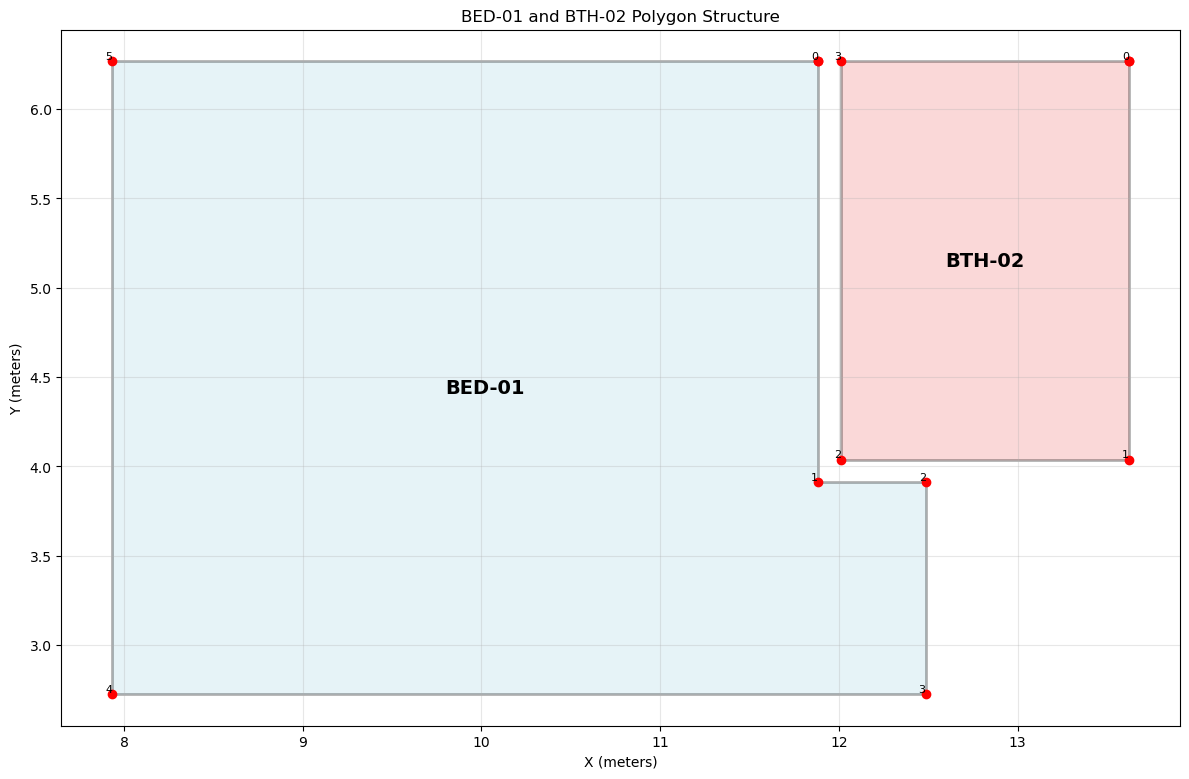


CONCLUSION

The rooms are SEPARATED by wall thickness (~0.19m).
The room polygons represent the INTERIOR SPACE, not including walls.

For L-shaped corners like BED-01 ↔ BTH-02:
1. They are close but don't touch (gap = wall thickness)
2. We need to place walls in the GAP between rooms
3. IN-01 should be horizontal wall in the gap
4. IN-02 should be vertical wall in the gap

Strategy: Use bbox overlap + gap midpoint to place walls!



In [15]:
# ============================================================================
# VISUALIZE: Room polygon vertices to understand structure
# ============================================================================

from rdflib import Graph, Namespace
import json
from shapely.geometry import shape
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon

RESPLAN = Namespace("http://resplan.org/resplan#")

ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"
graph = Graph()
graph.parse(ttl_path)

geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}

# Get room geometries
rooms_to_plot = ['BED-01', 'BTH-02']
room_geoms = {}

for space in graph.subjects():
    space_id = str(space).split('#')[-1]
    if space_id in rooms_to_plot:
        room_geoms[space_id] = shape(json.loads(str(geom_index[space])))

print("="*80)
print("ROOM POLYGON ANALYSIS")
print("="*80)

for room_id, geom in room_geoms.items():
    coords = list(geom.exterior.coords)
    print(f"\n{room_id}:")
    print(f"  Vertices: {len(coords)}")
    print(f"  Bounds: ({geom.bounds[0]:.2f}, {geom.bounds[1]:.2f}) → ({geom.bounds[2]:.2f}, {geom.bounds[3]:.2f})")
    print(f"  Coordinates:")
    for i, (x, y) in enumerate(coords):
        print(f"    [{i}] ({x:.3f}, {y:.3f})")

# Check gap between rooms
bed01 = room_geoms['BED-01']
bth02 = room_geoms['BTH-02']

distance = bed01.distance(bth02)
print(f"\n{'='*80}")
print(f"DISTANCE ANALYSIS")
print(f"{'='*80}")
print(f"Distance between BED-01 and BTH-02: {distance:.4f}m")

if distance > 0:
    from shapely.ops import nearest_points
    p1, p2 = nearest_points(bed01, bth02)
    print(f"Nearest point on BED-01: ({p1.x:.3f}, {p1.y:.3f})")
    print(f"Nearest point on BTH-02: ({p2.x:.3f}, {p2.y:.3f})")
    
    print(f"\n💡 KEY INSIGHT:")
    print(f"   Rooms are SEPARATED by {distance:.4f}m")
    print(f"   This gap is where the WALL should be!")
    print(f"   The wall thickness is approximately: {distance:.4f}m")
    print(f"   (Expected wall thickness: ~0.1897m)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'BED-01': 'lightblue', 'BTH-02': 'lightcoral'}

for room_id, geom in room_geoms.items():
    coords = list(geom.exterior.coords)
    x, y = zip(*coords)
    
    # Plot polygon
    poly = MPLPolygon(coords, fill=True, alpha=0.3, 
                      facecolor=colors[room_id], 
                      edgecolor='black', linewidth=2)
    ax.add_patch(poly)
    
    # Plot vertices
    ax.plot(x, y, 'o', color='red', markersize=6)
    
    # Label vertices
    for i, (xi, yi) in enumerate(coords[:-1]):  # Skip last (duplicate of first)
        ax.text(xi, yi, f'{i}', fontsize=8, ha='right', va='bottom')
    
    # Label room
    centroid = geom.centroid
    ax.text(centroid.x, centroid.y, room_id, 
            fontsize=14, weight='bold', ha='center', va='center')

# Add grid
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_title('BED-01 and BTH-02 Polygon Structure')

plt.tight_layout()
plt.savefig('../output/room_polygon_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✅ Saved visualization to: ../output/room_polygon_analysis.png")
plt.show()

print(f"\n{'='*80}")
print(f"CONCLUSION")
print(f"{'='*80}")
print("""
The rooms are SEPARATED by wall thickness (~0.19m).
The room polygons represent the INTERIOR SPACE, not including walls.

For L-shaped corners like BED-01 ↔ BTH-02:
1. They are close but don't touch (gap = wall thickness)
2. We need to place walls in the GAP between rooms
3. IN-01 should be horizontal wall in the gap
4. IN-02 should be vertical wall in the gap

Strategy: Use bbox overlap + gap midpoint to place walls!
""")

In [16]:
# ============================================================================
# FINAL SOLUTION: Infer Interior Walls for Separated Rooms
# Rooms are separated by wall thickness, not touching
# ============================================================================

import json
from shapely.geometry import shape, mapping, LineString
from shapely.ops import nearest_points

def infer_interior_wall_FINAL(
    graph,
    wall,
    adj_geom_index,
    geom_index,
    default_thickness=0.1897,
):
    """
    FINAL VERSION: Infer wall between rooms that are separated by gap.
    
    Strategy:
    1. Get room bounding boxes
    2. Determine overlap and gap
    3. Place wall in the gap at midpoint
    4. Use wall ID hint to determine horizontal vs vertical
    """
    
    def _load_shape(val):
        if val is None:
            return None
        if isinstance(val, dict):
            try:
                return shape(val)
            except:
                return None
        try:
            return shape(json.loads(str(val)))
        except:
            return None
    
    # Get adjacency and spaces
    derived = graph.value(wall, RESPLAN.derivedFrom)
    if not derived:
        return None
    
    spaceA = graph.value(derived, RESPLAN.spaceA)
    spaceB = graph.value(derived, RESPLAN.spaceB)
    
    if not spaceA or not spaceB:
        return None
    
    geomA = _load_shape(geom_index.get(spaceA))
    geomB = _load_shape(geom_index.get(spaceB))
    
    if not geomA or not geomB or geomA.is_empty or geomB.is_empty:
        return None
    
    spaceA_id = str(spaceA).split("#")[-1]
    spaceB_id = str(spaceB).split("#")[-1]
    wall_id = str(wall).split("#")[-1]
    
    # Get replaced wall info for hint
    replaced = graph.value(wall, RESPLAN.replacesWall)
    source_id = graph.value(replaced, RESPLAN.sourceId) if replaced else None
    hint = str(source_id) if source_id else wall_id
    
    # Get bounding boxes
    minxA, minyA, maxxA, maxyA = geomA.bounds
    minxB, minyB, maxxB, maxyB = geomB.bounds
    
    # Calculate overlaps
    x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
    y_overlap = min(maxyA, maxyB) - max(minyA, minyB)
    
    # Calculate gaps (when rooms don't overlap)
    x_gap = max(0, max(minxA, minxB) - min(maxxA, maxxB))
    y_gap = max(0, max(minyA, minyB) - min(maxyA, maxyB))
    
    wall_line = None
    orientation = None
    
    # =========================================================================
    # DECISION LOGIC based on hint
    # =========================================================================
    
    # Heuristic: IN-01 = horizontal, IN-02 = vertical (common convention)
    prefer_horizontal = 'in-01' in hint.lower() or '01' in hint
    prefer_vertical = 'in-02' in hint.lower() or '02' in hint
    
    # =========================================================================
    # CASE 1: Horizontal wall (rooms stacked vertically with Y gap)
    # =========================================================================
    if (y_gap > 0.05 or prefer_horizontal) and x_overlap > 0.1:
        # X overlap exists, Y gap exists → horizontal wall
        x_start = max(minxA, minxB)
        x_end = min(maxxA, maxxB)
        
        if minyA > maxyB:  # A is above B
            y_wall = (minyA + maxyB) / 2
        elif minyB > maxyA:  # B is above A
            y_wall = (minyB + maxyA) / 2
        else:
            # No gap but prefer horizontal - use overlap region
            y_wall = (max(minyA, minyB) + min(maxyA, maxyB)) / 2
        
        wall_line = LineString([(x_start, y_wall), (x_end, y_wall)])
        orientation = "HORIZONTAL"
    
    # =========================================================================
    # CASE 2: Vertical wall (rooms side-by-side with X gap)
    # =========================================================================
    elif (x_gap > 0.05 or prefer_vertical) and y_overlap > 0.1:
        # Y overlap exists, X gap exists → vertical wall
        y_start = max(minyA, minyB)
        y_end = min(maxyA, maxyB)
        
        if minxA > maxxB:  # A is to the right of B
            x_wall = (minxA + maxxB) / 2
        elif minxB > maxxA:  # B is to the right of A
            x_wall = (minxB + maxxA) / 2
        else:
            # No gap but prefer vertical - use overlap region
            x_wall = (max(minxA, minxB) + min(maxxA, maxxB)) / 2
        
        wall_line = LineString([(x_wall, y_start), (x_wall, y_end)])
        orientation = "VERTICAL"
    
    # =========================================================================
    # CASE 3: Fallback - nearest points
    # =========================================================================
    else:
        p1, p2 = nearest_points(geomA, geomB)
        if p1.distance(p2) < 0.5:
            wall_line = LineString([p1, p2])
            orientation = "FALLBACK"
    
    if not wall_line or wall_line.is_empty:
        return None
    
    # Create wall polygon
    wall_poly = wall_line.buffer(
        default_thickness / 2.0,
        cap_style=3,  # square caps
        join_style=2,  # mitre joins
    )
    
    if wall_poly.is_empty or wall_poly.area < 0.001:
        return None
    
    # Log result
    print(f"   ✅ {hint} → {wall_id} ({spaceA_id}↔{spaceB_id}):")
    print(f"      Orientation: {orientation}")
    print(f"      Length: {wall_line.length:.3f}m, Area: {wall_poly.area:.4f}m²")
    
    if orientation == "HORIZONTAL":
        y_wall = list(wall_line.coords)[0][1]
        x_start, x_end = min(wall_line.coords, key=lambda p: p[0])[0], max(wall_line.coords, key=lambda p: p[0])[0]
        print(f"      Position: Y={y_wall:.3f}, X=[{x_start:.3f}, {x_end:.3f}]")
    elif orientation == "VERTICAL":
        x_wall = list(wall_line.coords)[0][0]
        y_start, y_end = min(wall_line.coords, key=lambda p: p[1])[1], max(wall_line.coords, key=lambda p: p[1])[1]
        print(f"      Position: X={x_wall:.3f}, Y=[{y_start:.3f}, {y_end:.3f}]")
    
    return mapping(wall_poly)


# ============================================================================
# INTEGRATE into ttl_to_plan_dict
# ============================================================================

def ttl_to_plan_dict_FINAL_FIXED(ttl_path):
    """Final version with proper wall inference"""
    from pathlib import Path
    from rdflib import Graph, Namespace, RDF
    from rdflib.namespace import RDFS
    
    # Import helpers (adjust based on your structure)
    from thesis_package.ttl_to_json2 import (
        _local_id, _literal_float, _geom_props, _empty_instances,
        _room_type, _struct_type, _is_empty_geom,
        infer_door_geom_from_walls_or_adjacency,
        infer_window_geom_from_primary_and_hosts,
        RESPLAN, BOT, ROOM_KEYS, STRUCT_KEYS
    )
    
    ttl_path = Path(ttl_path)
    graph = Graph()
    graph.parse(ttl_path)

    geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}
    adj_geom_index = {
        a: g for a, g in graph.subject_objects(RESPLAN.geomJSON)
        if (a, RDF.type, RESPLAN.AdjacencyEdge) in graph
    }

    plan_dict = {"metadata": {}, "instances": _empty_instances()}

    # Metadata
    plan_node = next(graph.subjects(RDF.type, RESPLAN.ResPlan), None)
    if plan_node:
        label = graph.value(plan_node, RDFS.label)
        if label:
            plan_dict["metadata"]["plan_label"] = str(label)
        for pred, key in [(RESPLAN.planArea, "area"), (RESPLAN.netArea, "net_area")]:
            val = _literal_float(graph, plan_node, pred)
            if val:
                plan_dict["metadata"][key] = val
        unit_type = graph.value(plan_node, RESPLAN.unitType)
        if unit_type:
            plan_dict["metadata"]["unitType"] = str(unit_type)

    # Rooms
    for subj in graph.subjects(RDF.type, BOT.Space):
        geom_lit = graph.value(subj, RESPLAN.geomJSON)
        if not geom_lit:
            continue
        room_key = _room_type(graph, subj)
        if not room_key:
            continue
        plan_dict["instances"]["room"].setdefault(room_key, []).append({
            "id": _local_id(subj),
            "type": room_key,
            "geom": json.loads(str(geom_lit)),
            "props": _geom_props(graph, subj),
        })

    # Structural elements
    print("\n" + "="*80)
    print("INFERRING WALLS WITH FINAL SOLUTION")
    print("="*80)
    
    for struct_subj in set(graph.subjects(RDF.type, None)):
        struct_key = _struct_type(graph, struct_subj)
        if not struct_key or struct_key not in STRUCT_KEYS:
            continue

        own_geom_lit = graph.value(struct_subj, RESPLAN.geomJSON)
        geom_lit = own_geom_lit
        geom_dict = None

        # Fallbacks
        if _is_empty_geom(geom_lit):
            replaced = graph.value(struct_subj, RESPLAN.replacesWall)
            if replaced:
                geom_lit = geom_index.get(replaced)

        if _is_empty_geom(geom_lit):
            derived = graph.value(struct_subj, RESPLAN.derivedFrom)
            if derived:
                geom_lit = adj_geom_index.get(derived)

        # Infer geometries
        if struct_key == "door" and _is_empty_geom(own_geom_lit):
            geom_dict = infer_door_geom_from_walls_or_adjacency(
                graph, struct_subj, adj_geom_index, geom_index
            )

        if struct_key == "window" and _is_empty_geom(own_geom_lit):
            geom_dict = infer_window_geom_from_primary_and_hosts(
                graph, struct_subj, geom_index
            )

        # *** FINAL SOLUTION: Use hint-based inference ***
        if (struct_key == "interior_wall" and 
            _is_empty_geom(own_geom_lit) and 
            _is_empty_geom(geom_lit)):
            
            geom_dict = infer_interior_wall_FINAL(
                graph, struct_subj, adj_geom_index, geom_index
            )

        # Use geometry
        if geom_dict:
            geom = geom_dict
        elif not _is_empty_geom(geom_lit):
            geom = geom_lit if isinstance(geom_lit, dict) else json.loads(str(geom_lit))
        else:
            continue

        # Normalize walls
        if struct_key in {"interior_wall", "exterior_wall"}:
            try:
                shp = shape(geom)
                if shp.geom_type in {"LineString", "MultiLineString"}:
                    shp = shp.buffer(0.06, cap_style=2, join_style=2)
                geom = mapping(shp)
            except:
                pass

        is_inferred_lit = graph.value(struct_subj, RESPLAN.isInferred)
        inferred_flag = (
            is_inferred_lit.toPython() if is_inferred_lit
            else ("infer#" in str(struct_subj))
        )

        record_id = (
            _local_id(struct_subj) if inferred_flag
            else (graph.value(struct_subj, RESPLAN.sourceId) or _local_id(struct_subj))
        )

        plan_dict["instances"]["structural"].setdefault(struct_key, []).append({
            "id": str(record_id),
            "type": struct_key,
            "geom": geom,
            "props": _geom_props(graph, struct_subj),
            "inferred": inferred_flag,
        })

    return plan_dict

print("✅ FINAL SOLUTION defined!")
print("Use: infer_interior_wall_FINAL() for inference")
print("Use: ttl_to_plan_dict_FINAL_FIXED() for full conversion")

✅ FINAL SOLUTION defined!
Use: infer_interior_wall_FINAL() for inference
Use: ttl_to_plan_dict_FINAL_FIXED() for full conversion


In [18]:
# Di file utama kamu
from thesis_package.ttl_to_json2 import ttl_to_plan_dict_FINAL_FIXED

# Gunakan fungsi baru
plan_dict = ttl_to_plan_dict_FINAL_FIXED("../output/inferred_resplan_ttl/plan_00000_walls_back.ttl")

ImportError: cannot import name 'ttl_to_plan_dict_FINAL_FIXED' from 'thesis_package.ttl_to_json2' (/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/thesis_package/ttl_to_json2.py)

# DEBUG

In [4]:
# ============================================================================
# JUPYTER NOTEBOOK: Debug Inferred Interior Walls
# ============================================================================
# Copy seluruh cell ini ke Jupyter Notebook Anda

# Cell 1: Setup
from rdflib import Graph, Namespace
from shapely.geometry import shape, mapping, LineString, MultiLineString, GeometryCollection
from shapely.ops import linemerge, unary_union, nearest_points
import json

RESPLAN = Namespace("http://resplan.org/resplan#")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [5]:
# ============================================================================
# Cell 2: Helper Functions
# ============================================================================

def _load_shape(val):
    """Load shapely geometry from RDF literal or dict"""
    if val is None:
        return None
    if isinstance(val, dict):
        try:
            return shape(val)
        except:
            return None
    try:
        return shape(json.loads(str(val)))
    except:
        return None

def _as_lines(geom):
    """Convert geometry to list of LineStrings"""
    if geom is None or geom.is_empty:
        return []
    if isinstance(geom, LineString):
        return [geom]
    if isinstance(geom, MultiLineString):
        return list(geom.geoms)
    if isinstance(geom, GeometryCollection):
        out = []
        for g in geom.geoms:
            out.extend(_as_lines(g))
        return out
    return []

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [6]:
# ============================================================================
# Cell 3: Debug Function - Analyze Adjacencies
# ============================================================================

def debug_adjacency(ttl_path):
    """Analisis adjacency edges yang butuh inferred walls"""
    graph = Graph()
    print(f"📖 Loading TTL file: {ttl_path}")
    graph.parse(ttl_path)
    
    # Collect geometry index
    geom_index = {
        subj: geom for subj, geom in graph.subject_objects(RESPLAN.geomJSON)
    }
    
    adj_geom_index = {
        adj: geom
        for adj, geom in graph.subject_objects(RESPLAN.geomJSON)
        if (adj, RDF.type, RESPLAN.AdjacencyEdge) in graph
    }
    
    print(f"✅ Found {len(geom_index)} geometries, {len(adj_geom_index)} adjacencies")
    print("\n" + "=" * 80)
    print("ADJACENCY EDGES YANG MENGHASILKAN INFERRED WALLS")
    print("=" * 80)
    
    # Cari semua inferred walls dan adjacency-nya
    inferred_count = 0
    for adj_subj in graph.subjects(RDF.type, RESPLAN.AdjacencyEdge):
        # Check if this adjacency produces an inferred wall
        has_inferred = False
        for wall in graph.subjects(RESPLAN.derivedFrom, adj_subj):
            is_inf = graph.value(wall, RESPLAN.isInferred)
            if is_inf and is_inf.toPython():
                has_inferred = True
                break
        
        if not has_inferred:
            continue
            
        inferred_count += 1
        adj_id = str(adj_subj).split("#")[-1]
        
        print(f"\n📍 Adjacency #{inferred_count}: {adj_id}")
        print("-" * 80)
        
        # Get spaces
        spaceA = graph.value(adj_subj, RESPLAN.spaceA)
        spaceB = graph.value(adj_subj, RESPLAN.spaceB)
        
        spaceA_id = str(spaceA).split("#")[-1] if spaceA else "?"
        spaceB_id = str(spaceB).split("#")[-1] if spaceB else "?"
        
        print(f"   Spaces: {spaceA_id} ↔ {spaceB_id}")
        
        # Get adjacency geometry
        adj_geom_lit = adj_geom_index.get(adj_subj)
        if adj_geom_lit:
            try:
                adj_geom = json.loads(str(adj_geom_lit))
                adj_type = adj_geom.get('type', 'Unknown')
                coords = adj_geom.get('coordinates', [])
                
                print(f"   Adjacency Type: {adj_type}")
                if coords:
                    if adj_type == "LineString":
                        print(f"   Adjacency Coords: {len(coords)} points")
                    else:
                        print(f"   Adjacency Coords: {coords}")
                else:
                    print(f"   ⚠️  Adjacency Coords: EMPTY ❌")
            except Exception as e:
                print(f"   ❌ Cannot parse adjacency geometry: {e}")
        else:
            print(f"   ❌ No adjacency geometry found in index")
        
        # Get and analyze space geometries
        if spaceA and spaceB:
            geomA_lit = geom_index.get(spaceA)
            geomB_lit = geom_index.get(spaceB)
            
            if geomA_lit and geomB_lit:
                try:
                    geomA = shape(json.loads(str(geomA_lit)))
                    geomB = shape(json.loads(str(geomB_lit)))
                    
                    print(f"\n   Space {spaceA_id}:")
                    print(f"      Type: {geomA.geom_type}, Area: {geomA.area:.2f}")
                    print(f"   Space {spaceB_id}:")
                    print(f"      Type: {geomB.geom_type}, Area: {geomB.area:.2f}")
                    
                    # Check shared boundary
                    shared = geomA.boundary.intersection(geomB.boundary)
                    print(f"\n   Shared Boundary Analysis:")
                    print(f"      Type: {shared.geom_type}")
                    print(f"      Length: {shared.length:.4f} m")
                    
                    if shared.length > 0.05:
                        print(f"      ✅ Sufficient length for wall creation")
                        
                        # Show boundary coordinates
                        if shared.geom_type == "LineString":
                            coords = list(shared.coords)
                            print(f"      Start: ({coords[0][0]:.2f}, {coords[0][1]:.2f})")
                            print(f"      End:   ({coords[-1][0]:.2f}, {coords[-1][1]:.2f})")
                    else:
                        print(f"      ⚠️  Too short for wall creation")
                        
                        # Try nearest points as fallback
                        p1, p2 = nearest_points(geomA, geomB)
                        dist = p1.distance(p2)
                        print(f"      Nearest points distance: {dist:.4f} m")
                        print(f"      Point A: ({p1.x:.2f}, {p1.y:.2f})")
                        print(f"      Point B: ({p2.x:.2f}, {p2.y:.2f})")
                        
                except Exception as e:
                    print(f"   ❌ Error analyzing spaces: {e}")
            else:
                print(f"   ❌ Missing space geometries:")
                print(f"      Space A geom: {'✅' if geomA_lit else '❌'}")
                print(f"      Space B geom: {'✅' if geomB_lit else '❌'}")
    
    print("\n" + "=" * 80)
    print(f"Total inferred wall adjacencies found: {inferred_count}")
    return graph, geom_index, adj_geom_index

print("✅ Debug function defined!")

✅ Debug function defined!


In [7]:
# ============================================================================
# Cell 4: Improved Inference Function
# ============================================================================

def improved_infer_interior_wall_geom(
    graph,
    wall,
    adj_geom_index,
    geom_index,
    default_thickness=0.19,
    min_seg_len=0.05,
):
    """
    Improved version dengan lebih banyak fallback strategies
    """
    
    # Strategy 0: Check if already has geometry
    existing = _load_shape(geom_index.get(wall))
    if existing and not existing.is_empty and existing.geom_type in {"Polygon", "MultiPolygon"}:
        return mapping(existing)
    
    # Get derivedFrom adjacency
    derived = graph.value(wall, RESPLAN.derivedFrom)
    if not derived:
        print(f"      ❌ No derivedFrom adjacency")
        return None
    
    # Get spaces from adjacency
    spaceA = graph.value(derived, RESPLAN.spaceA)
    spaceB = graph.value(derived, RESPLAN.spaceB)
    
    if not spaceA or not spaceB:
        print(f"      ❌ Missing spaces")
        return None
    
    # Load space geometries
    geomA = _load_shape(geom_index.get(spaceA))
    geomB = _load_shape(geom_index.get(spaceB))
    
    if not geomA or not geomB or geomA.is_empty or geomB.is_empty:
        print(f"      ❌ Invalid space geometries")
        return None
    
    spaceA_id = str(spaceA).split("#")[-1]
    spaceB_id = str(spaceB).split("#")[-1]
    
    # Strategy 1: Use adjacency geometry if it's a polygon
    adj_geom_lit = adj_geom_index.get(derived)
    if adj_geom_lit:
        try:
            adj_shp = _load_shape(adj_geom_lit)
            if adj_shp and not adj_shp.is_empty:
                if adj_shp.geom_type in {"Polygon", "MultiPolygon"}:
                    print(f"      ✅ Using adjacency polygon (area: {adj_shp.area:.3f})")
                    return mapping(adj_shp)
        except:
            pass
    
    # Strategy 2: Compute shared boundary
    shared = geomA.boundary.intersection(geomB.boundary)
    lines = [l for l in _as_lines(shared) if l.length >= min_seg_len]
    
    if not lines:
        # FALLBACK: Create wall at closest points
        p1, p2 = nearest_points(geomA, geomB)
        line = LineString([p1, p2])
        print(f"      🔧 Using nearest points (distance: {line.length:.3f})")
    else:
        # Merge and take longest segment
        merged = linemerge(unary_union(lines))
        merged_lines = _as_lines(merged)
        if not merged_lines:
            merged_lines = lines
        
        line = max(merged_lines, key=lambda x: x.length)
        print(f"      ✅ Using shared boundary (length: {line.length:.3f})")
    
    # Check if exterior boundary (reject if so)
    union = geomA.union(geomB)
    inter_len = line.intersection(union.boundary).length
    if line.length > 0.001 and (inter_len / line.length) > 0.8:
        print(f"      ⚠️  On exterior boundary - REJECTED")
        return None
    
    # Buffer to create wall polygon
    wall_poly = line.buffer(
        default_thickness / 2.0,
        cap_style=3,  # square
        join_style=2,  # mitre
    )
    
    if wall_poly.is_empty or wall_poly.area < 0.001:
        print(f"      ❌ Wall too small (area: {wall_poly.area:.6f})")
        return None
    
    print(f"      ✅ Created wall (area: {wall_poly.area:.3f})")
    return mapping(wall_poly)

print("✅ Improved inference function defined!")

✅ Improved inference function defined!


In [8]:
# ============================================================================
# Cell 5: RUN DEBUG ANALYSIS
# ============================================================================

# Sesuaikan path file TTL Anda di sini:
ttl_path = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"

print("🚀 Starting debug analysis...\n")
graph, geom_index, adj_geom_index = debug_adjacency(ttl_path)

🚀 Starting debug analysis...

📖 Loading TTL file: ../output/inferred_resplan_ttl/plan_00000_walls_back.ttl
✅ Found 99 geometries, 43 adjacencies

ADJACENCY EDGES YANG MENGHASILKAN INFERRED WALLS

📍 Adjacency #1: adj-BED-01-BTH-01-IN-05
--------------------------------------------------------------------------------
   Spaces: BED-01 ↔ BTH-01
   Adjacency Type: LineString
   ⚠️  Adjacency Coords: EMPTY ❌

   Space BED-01:
      Type: Polygon, Area: 14.70
   Space BTH-01:
      Type: Polygon, Area: 3.52

   Shared Boundary Analysis:
      Type: LineString
      Length: 0.0000 m
      ⚠️  Too short for wall creation
      Nearest points distance: 0.1264 m
      Point A: (7.93, 5.16)
      Point B: (7.81, 5.16)

📍 Adjacency #2: adj-BED-01-BTH-02-IN-01
--------------------------------------------------------------------------------
   Spaces: BED-01 ↔ BTH-02
   Adjacency Type: LineString
   ⚠️  Adjacency Coords: EMPTY ❌

   Space BED-01:
      Type: Polygon, Area: 14.70
   Space BTH-02:
   

In [9]:
# ============================================================================
# Cell 6: TEST IMPROVED INFERENCE
# ============================================================================

print("\n" + "=" * 80)
print("TESTING IMPROVED INFERENCE FUNCTION")
print("=" * 80)

test_count = 0
success_count = 0

for wall_subj in graph.subjects(RDF.type, RESPLAN.InteriorWall):
    is_inferred = graph.value(wall_subj, RESPLAN.isInferred)
    if is_inferred and is_inferred.toPython():
        test_count += 1
        wall_id = str(wall_subj).split("#")[-1]
        print(f"\n🔨 Test #{test_count}: {wall_id}")
        
        result = improved_infer_interior_wall_geom(
            graph, wall_subj, adj_geom_index, geom_index
        )
        
        if result:
            success_count += 1
            coord_count = len(result.get('coordinates', [[]])[0]) if result.get('coordinates') else 0
            print(f"   ✅ SUCCESS: {result['type']} with {coord_count} vertices")
        else:
            print(f"   ❌ FAILED: No geometry generated")

print("\n" + "=" * 80)
print(f"SUMMARY: {success_count}/{test_count} walls successfully inferred")
print("=" * 80)


TESTING IMPROVED INFERENCE FUNCTION

🔨 Test #1: IW-INF-509ed072-20ac-496a-81b7-8b6721be950a
      🔧 Using nearest points (distance: 0.126)
      ✅ Created wall (area: 0.060)
   ✅ SUCCESS: Polygon with 7 vertices

🔨 Test #2: IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1
      🔧 Using nearest points (distance: 0.126)
      ✅ Created wall (area: 0.060)
   ✅ SUCCESS: Polygon with 7 vertices

🔨 Test #3: IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7
      🔧 Using nearest points (distance: 0.126)
      ✅ Created wall (area: 0.060)
   ✅ SUCCESS: Polygon with 7 vertices

SUMMARY: 3/3 walls successfully inferred


# Door

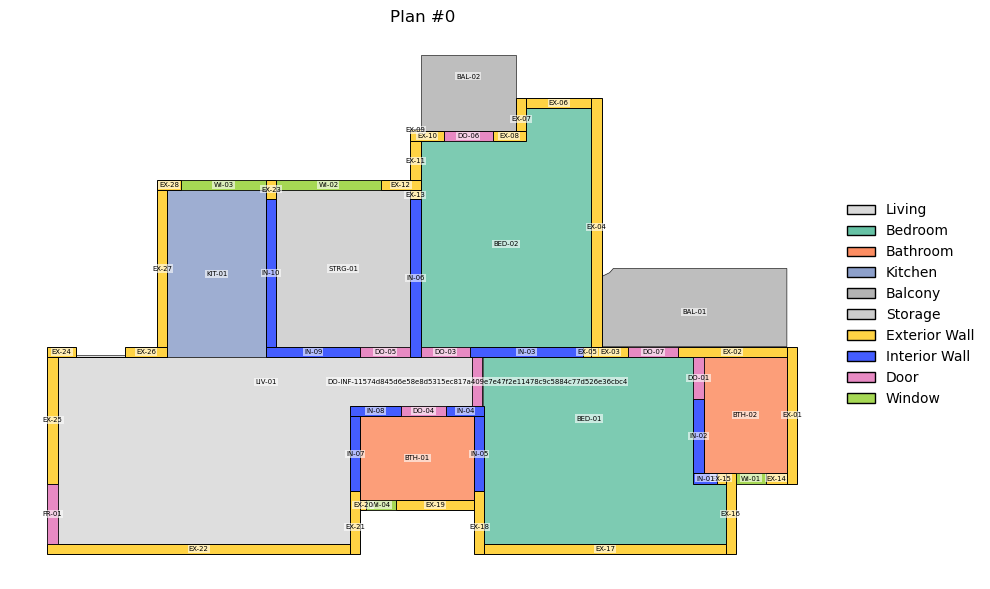

In [4]:
from thesis_package.ttl_to_json import save_ttl_as_json
from thesis_package.visualize import plot_plan_json


save_ttl_as_json(
    "../output/inferred_resplan_ttl/plan_00000_doors_back.ttl",
    "../output/inferred_resplan_json/plan_00000_doors_back.json",
)

ax = plot_plan_json("../output/inferred_resplan_json/plan_00000_doors_back.json",
                    show_wall_ids=True, show_ids=True)



# Window

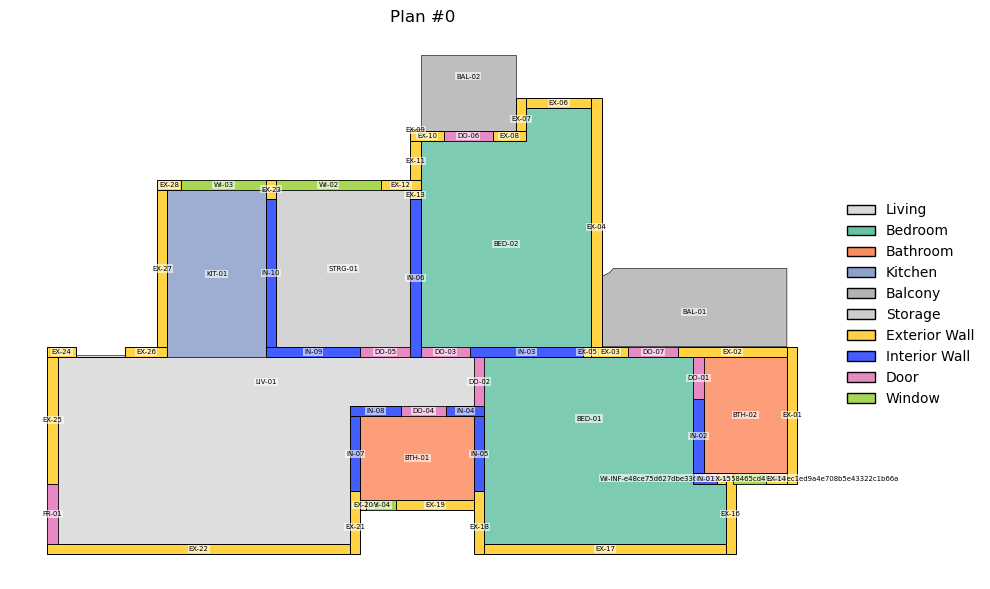

In [4]:
from thesis_package.ttl_to_json import save_ttl_as_json
from thesis_package.visualize import plot_plan_json


save_ttl_as_json(
    "../output/inferred_resplan_ttl/plan_00000_windows_back.ttl",
    "../output/inferred_resplan_json/plan_00000_windows_back.json",
)

ax = plot_plan_json("../output/inferred_resplan_json/plan_00000_windows_back.json",
                    show_wall_ids=True, show_ids=True)

